# Heart Disease UCI — Cleveland Analysis

## 1. Setup

Imports for data handling, visualization and modelling.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV, cross_validate, StratifiedKFold
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

## 2. Data Loading

Using the Cleveland subset of the UCI Heart Disease dataset. Missing values are marked as `?` so we drop them. Target is binarized: 0 = no disease, 1 = disease.

In [26]:
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv('data/processed.cleveland.data', # We begin only with Cleveland
                 names=columns,
                 na_values='?').dropna()

df['target']= (df['target']>0).astype(int)

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


## 3. Exploratory Data Analysis

Quick look at age and sex distributions, then correlation heatmap to get a sense of which features might matter.

### 3.1 Distribution Plots

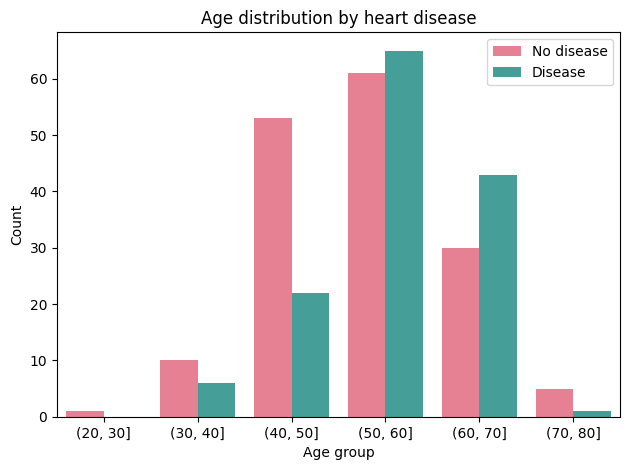

In [27]:
#age range
def histo_age(df):
    df['age_group'] = pd.cut(df['age'],bins=[20,30,40,50,60,70,80])

    palette = sns.color_palette('husl',2)

    sns.countplot(data=df, x='age_group',hue='target', palette=palette,legend=['no disease','disease'])
    plt.title('Age distribution by heart disease')
    plt.xlabel('Age group')
    plt.ylabel('Count')
    plt.legend(labels=['No disease', 'Disease'])
    plt.tight_layout()
    plt.show()
  

histo_age(df)
df = df.drop('age_group',axis=1)

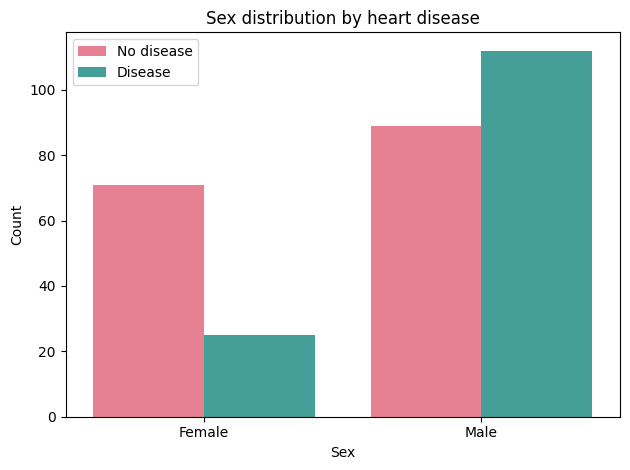

In [28]:
#Histogram by sex

def histo_sex(df):
    palette = sns.color_palette('husl',2)
    sns.countplot(data=df, x='sex', hue='target', palette=palette)
    plt.legend(labels=['No disease','Disease'])
    plt.xlabel('Sex')
    plt.ylabel('Count')
    plt.xticks([0,1],['Female','Male'])
    plt.title('Sex distribution by heart disease')
    plt.tight_layout()
    plt.show()

histo_sex(df)

### 3.2 Correlation Analysis

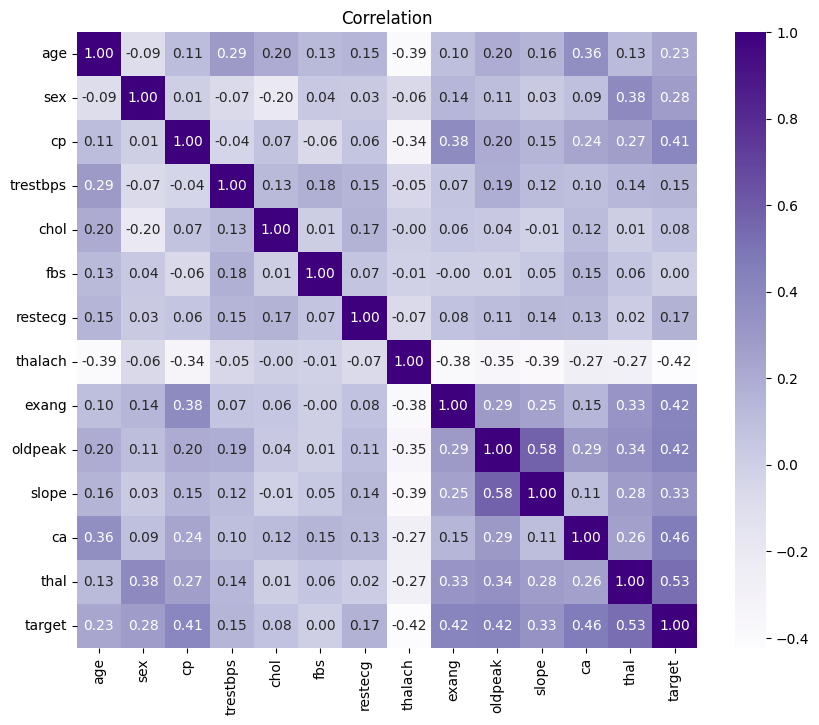

In [29]:
#Correlation
def corr_(df):
    plt.figure(figsize=(10,8))
    sns.heatmap(df.corr(), cmap="Purples",annot=True, fmt=".2f")
    plt.title("Correlation")
    plt.show()

corr_(df)

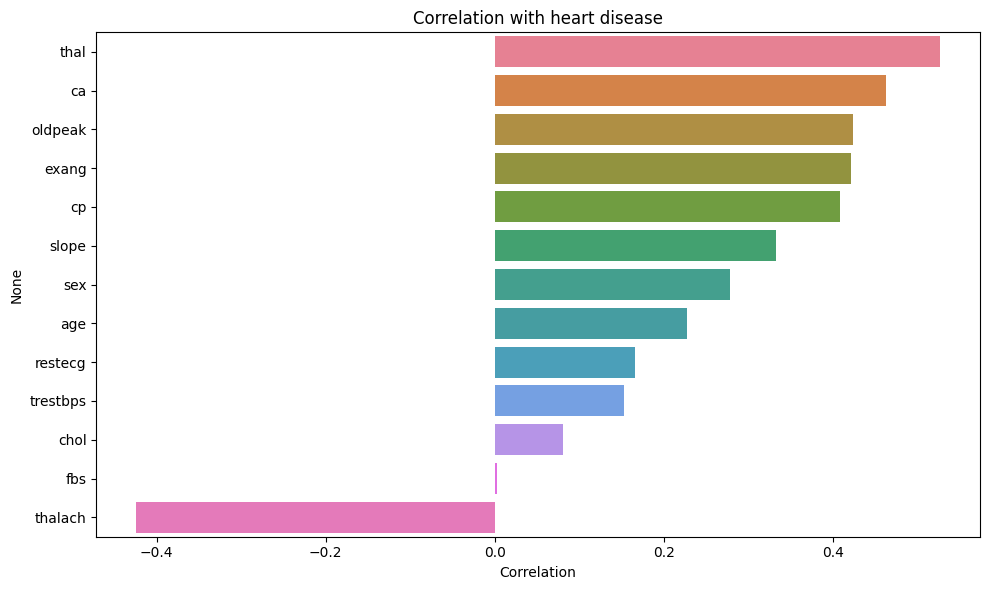

In [30]:
#Special correlation between target and features
def special_corr_(df):
    plt.figure(figsize=(10, 6))
    corr = df.corr()['target'].drop('target').sort_values(ascending=False)
    palette = sns.color_palette('husl', len(corr))
    sns.barplot(x=corr.values, y=corr.index, hue=corr.index, palette=palette )
    plt.title('Correlation with heart disease')
    plt.xlabel('Correlation')
    plt.tight_layout()
    plt.show()

special_corr_(df)

## 4. Preprocessing

Split into train/test (stratified to keep class balance), then standardize. Scaler is fit only on train to avoid leakage.

In [31]:
Y = df['target']
X = df.drop('target',axis=1)


X_train, X_test, Y_train, Y_test = train_test_split(X,Y, stratify=Y, random_state=42)

#Standardisation
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

## 5. Baseline Models

Training a few classifiers with default params to see where we start. Using 5-fold stratified CV to compare them.

In [32]:
clf_XGB = XGBClassifier(random_state=42).fit(X_train, Y_train)

clf_KNN = KNeighborsClassifier().fit(X_train, Y_train)

clf_Forest = RandomForestClassifier(random_state=42).fit(X_train, Y_train)

clf_Log = LogisticRegression(max_iter=5000,random_state=42).fit(X_train, Y_train)

clf_SVC = SVC(random_state=42).fit(X_train, Y_train)

clf_Tree = DecisionTreeClassifier(random_state=42).fit(X_train,Y_train)

models = {
    "XGboost": clf_XGB,
    "KNN": clf_KNN,
    "Random Forest": clf_Forest,
    "Logistic Regression": clf_Log,
    "SVM": clf_SVC,
    'Tree': clf_Tree
}

In [33]:
def cross_result(X, Y, models, cv=5):
    results = []
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    for name, model in models.items():

        scores  = cross_validate(model, X, Y, cv=skf, scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'])

        results.append([
            name,
            scores['test_accuracy'].mean(),
            scores['test_accuracy'].std(),
            scores['test_precision_macro'].mean(),
            scores['test_recall_macro'].mean(),
            scores['test_f1_macro'].mean(),
            scores['test_f1_macro'].std()
        ])

    results_df = pd.DataFrame(results, columns=["Model",'Accuracy','Accuracy std','Precision','Recall', 'f1 score', 'f1 score std'])
    results_df = results_df.sort_values("Accuracy", ascending=False)

    return results_df

cross_result(X, Y,models)

,Model,Accuracy,Accuracy std,Precision,Recall,f1 score,f1 score std
3,Logistic Regression,0.831525,0.024633,0.833919,0.828158,0.829157,0.026014
2,Random Forest,0.807966,0.048803,0.809681,0.804679,0.805631,0.049345
0,XGboost,0.794407,0.047707,0.798230,0.791468,0.791696,0.048119
5,Tree,0.720565,0.026883,0.729825,0.720271,0.716536,0.026685
1,KNN,0.666384,0.050720,0.667837,0.660913,0.659001,0.053526
4,SVM,0.663164,0.057594,0.678349,0.647801,0.640547,0.062088


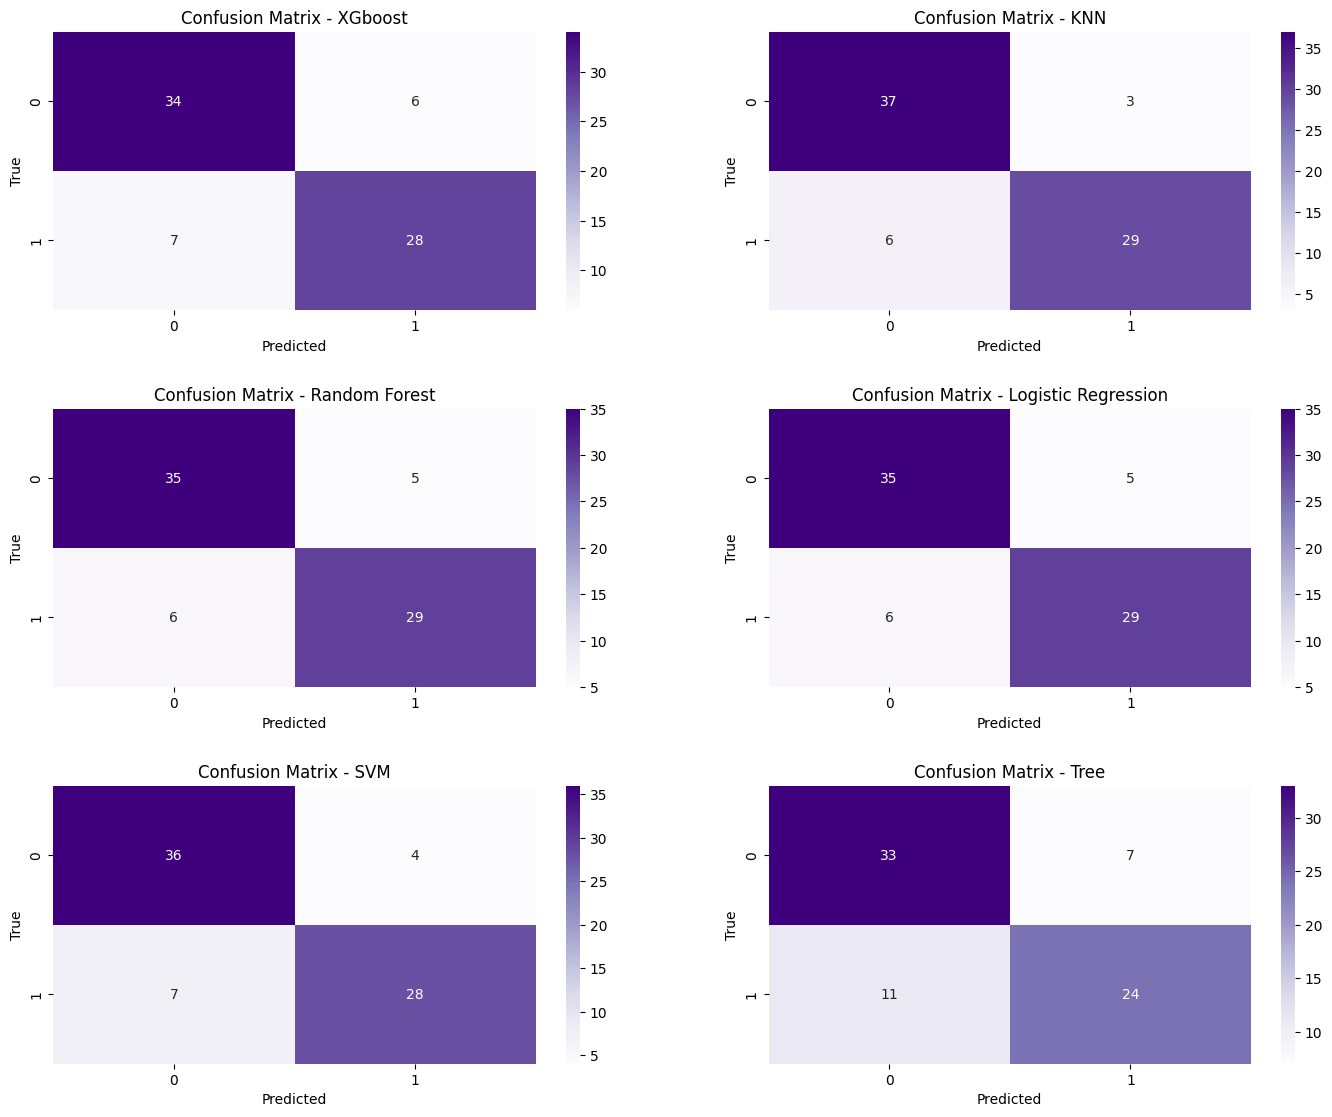

In [34]:
def confusion(X_test,Y_test, models, n_row=3,n_col=2):
    fig, axes = plt.subplots(nrows=n_row,ncols=n_col, figsize=(15,12), squeeze=False)
    plt.tight_layout(pad = 5.0)

    for i,(name, model) in enumerate(models.items()):
        row = i// n_col
        col = i%n_col

        y_pred = model.predict(X_test)
        cm = confusion_matrix(Y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d',cmap='Purples', xticklabels=np.unique(Y_test), yticklabels=np.unique(Y_test), ax=axes[row, col])
        axes[row, col].set_xlabel("Predicted")
        axes[row, col].set_ylabel("True")
        axes[row, col].set_title(f"Confusion Matrix - {name}")


    for j in range(len(models), n_row * n_col):
        axes[j // n_col, j % n_col].set_visible(False)

    plt.show()

confusion(X_test,Y_test, models)


All baseline models land around the same accuracy, which makes sense given the dataset size.
Going to focus on SVC, Logistic Regression and XGBoost for tuning.

## 6. Hyperparameter Tuning

Using `RandomizedSearchCV` with 5-fold stratified CV on the three selected models.

Optimizing for **recall** because in a medical context, a false negative (missing a sick patient) is much worse than a false positive (flagging a healthy one). Better to over-refer than to miss a diagnosis.

In [35]:
#SVC Optimisation

param_grid_SVC = {
    'C': [0.1, 1, 10, 100,150,200,250,300,350,400],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_SVC = RandomizedSearchCV(clf_SVC, param_grid_SVC, cv=skf, scoring='recall',n_iter=10, n_jobs=-1, random_state=42)
grid_search_SVC.fit(X_train, Y_train)

print('Best hyperparameters: ', grid_search_SVC.best_params_)
print('Best cross-validation score: ', grid_search_SVC.best_score_)

y_pred_test = grid_search_SVC.predict(X_test)
y_pred_train = grid_search_SVC.predict(X_train)

print('Accuracy on the test: ',accuracy_score(Y_test,y_pred_test))
print('Accuracy on the train: ',accuracy_score(Y_train,y_pred_train))

clf_SVC_best = grid_search_SVC.best_estimator_


Best hyperparameters:  {'kernel': 'linear', 'gamma': 0.001, 'C': 100}
Best cross-validation score:  0.8023809523809524
Accuracy on the test:  0.8666666666666667
Accuracy on the train:  0.8333333333333334


In [36]:
#Log Optimisation

param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_log = RandomizedSearchCV(clf_Log, param_grid_log, cv=skf, scoring='recall',n_iter=10, n_jobs=-1, random_state=42)
grid_search_log.fit(X_train, Y_train)

print('Best hyperparameters: ', grid_search_log.best_params_)
print('Best cross-validation score: ', grid_search_log.best_score_)

y_pred_test = grid_search_log.predict(X_test)
y_pred_train = grid_search_log.predict(X_train)

print('Accuracy on the test: ',accuracy_score(Y_test,y_pred_test))
print('Accuracy on the train: ',accuracy_score(Y_train,y_pred_train))

clf_Log_best = grid_search_log.best_estimator_

Best hyperparameters:  {'solver': 'lbfgs', 'C': 10}
Best cross-validation score:  0.7923809523809524
Accuracy on the test:  0.8533333333333334
Accuracy on the train:  0.8333333333333334


In [37]:
#XGBoost Optimisation

from scipy.stats import randint, uniform

param_grid_xgb = {
    'max_depth': randint(2, 5),          
    'learning_rate': uniform(0.01, 0.1),
    'n_estimators': randint(50, 150),    
    'subsample': uniform(0.6, 0.3),
    'colsample_bytree': uniform(0.5, 0.3),
    'reg_alpha': uniform(0, 2),          
    'reg_lambda': uniform(1, 10),        
    'min_child_weight': randint(3, 10),  
    'gamma': uniform(0.1, 0.5)   
}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_xgb = RandomizedSearchCV(clf_XGB, param_grid_xgb, cv=skf, scoring='recall',n_iter=30, n_jobs=-1, random_state=42)
grid_search_xgb.fit(X_train, Y_train)

print('Best hyperparameters: ', grid_search_xgb.best_params_)
print('Best cross-validation score: ', grid_search_xgb.best_score_)

y_pred_test = grid_search_xgb.predict(X_test)
y_pred_train = grid_search_xgb.predict(X_train)

print('Accuracy on the test: ',accuracy_score(Y_test,y_pred_test))
print('Accuracy on the train: ',accuracy_score(Y_train,y_pred_train))

clf_XGB_best = grid_search_xgb.best_estimator_

Best hyperparameters:  {'colsample_bytree': np.float64(0.5536468127663986), 'gamma': np.float64(0.28323439229143), 'learning_rate': np.float64(0.08441705230565623), 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 82, 'reg_alpha': np.float64(1.0850804611097986), 'reg_lambda': np.float64(6.0881407683876), 'subsample': np.float64(0.7908997854557686)}
Best cross-validation score:  0.8028571428571428
Accuracy on the test:  0.84
Accuracy on the train:  0.8873873873873874


### Comparison after tuning

Checking if tuning actually helped vs the baselines.

In [38]:
models = {
    "XGboost": clf_XGB,
    "XGBoost - Best": clf_XGB_best,
    "Logistic Regression": clf_Log,
    "Logistic Regression - Best": clf_Log_best,
    "SVM": clf_SVC,
    'SVM - Best': clf_SVC_best

}
cross_result(X,Y,models)

,Model,Accuracy,Accuracy std,Precision,Recall,f1 score,f1 score std
2,Logistic Regression,0.831525,0.024633,0.833919,0.828158,0.829157,0.026014
1,XGBoost - Best,0.828023,0.053453,0.829763,0.824454,0.825838,0.054025
3,Logistic Regression - Best,0.818023,0.036749,0.821298,0.814054,0.815026,0.038389
5,SVM - Best,0.801299,0.019947,0.808880,0.797718,0.797826,0.019831
0,XGboost,0.794407,0.047707,0.798230,0.791468,0.791696,0.048119
4,SVM,0.663164,0.057594,0.678349,0.647801,0.640547,0.062088


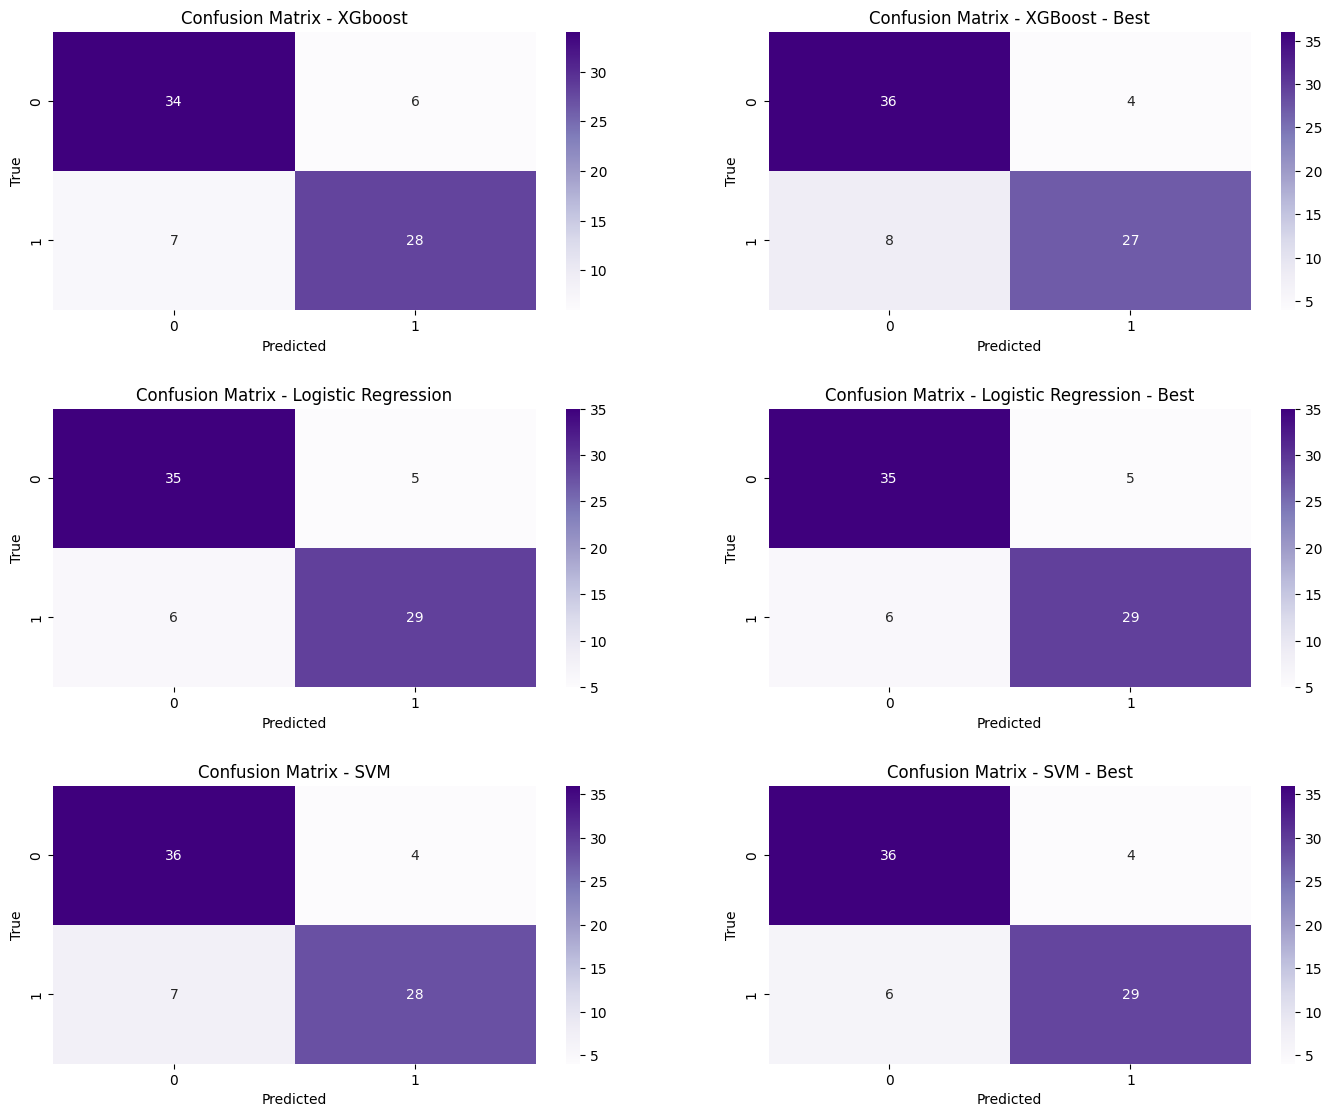

In [39]:
confusion(X_test,Y_test, models)

Tuning didn't change much. Probably because the dataset is small (~300 samples) — not a lot of room for the models to improve.

## 7. Feature Importance

Using three different methods to figure out which features actually drive predictions:
- `feature_importances_` for XGBoost
- Coefficients for LR and SVC
- Permutation importance for all three (more reliable, model-agnostic)

### 7.1 XGBoost — Feature Importance (gain)

In [40]:
#XGBoost

importances_XGB = clf_XGB_best.feature_importances_
print(pd.Series(importances_XGB, index=X.columns).sort_values(ascending=False).head(14))

plot_importance(clf_XGB_best, importance_type='gain')

thal        0.218315
cp          0.199641
ca          0.125516
oldpeak     0.071534
exang       0.069393
slope       0.054521
sex         0.047385
chol        0.044720
trestbps    0.039413
restecg     0.036455
thalach     0.035940
age         0.034190
fbs         0.022977
dtype: float32


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

### 7.2 Logistic Regression — Coefficients

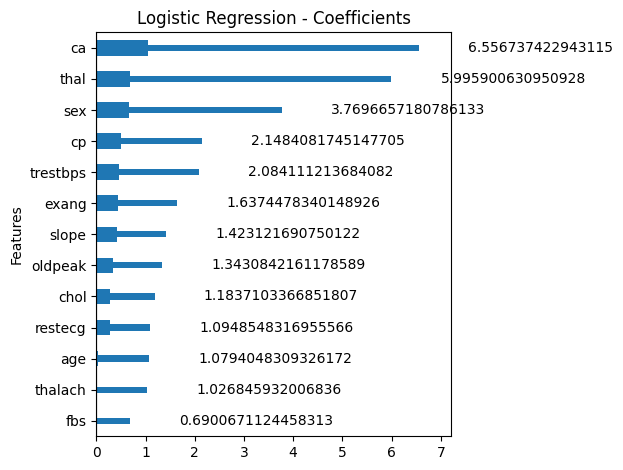

In [41]:
# Logistic Regression

importances_log = pd.Series(clf_Log_best.coef_[0], index = X.columns).sort_values()
importances_log.plot(kind='barh', title="Logistic Regression - Coefficients")   
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 7.3 Linear SVC — Coefficients

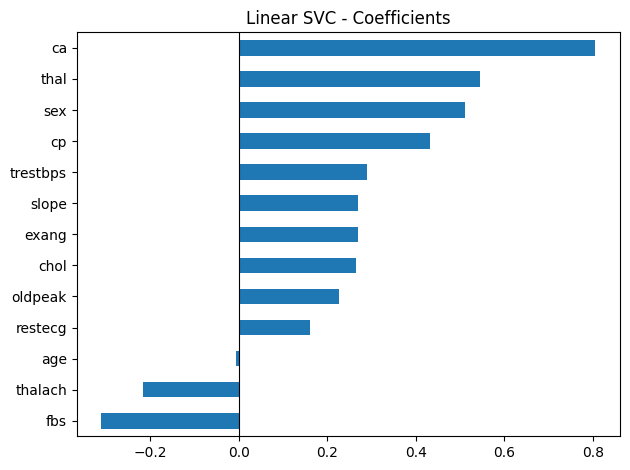

In [42]:
#SVC
coef_svc = pd.Series(clf_SVC_best.coef_[0], index=X.columns)
coef_svc.sort_values().plot(kind='barh', title="Linear SVC - Coefficients")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### 7.4 Permutation Importance

Computed on test set, 30 repetitions. Error bars show variance across repetitions.

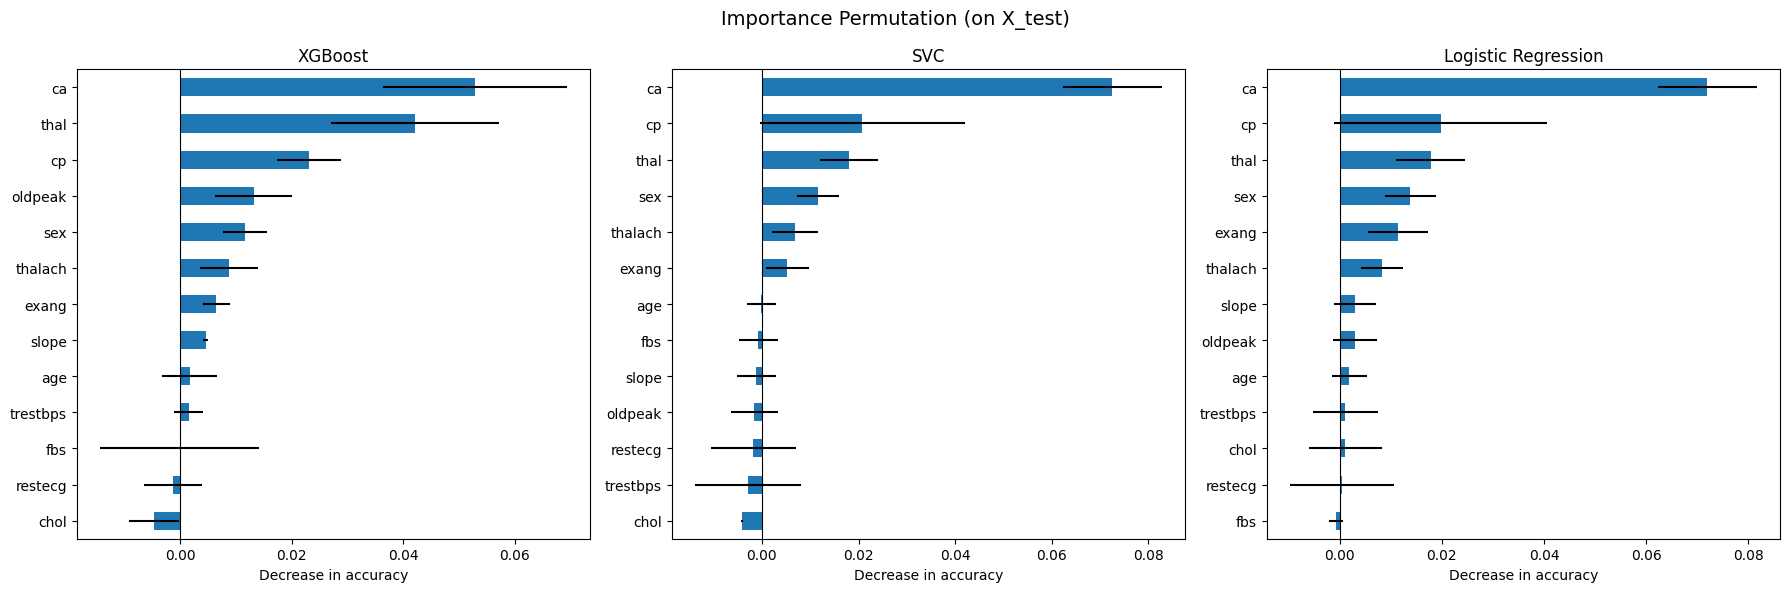

In [43]:
models = [
    ("XGBoost", clf_XGB_best),
    ("SVC", clf_SVC_best),
    ("Logistic Regression", clf_Log_best)
]

def perm_importance(X_test, Y_test, models):
    fig, axes = plt.subplots(1,3,figsize=(18,6))

    for ax, (name, model) in zip(axes, models):
        result = permutation_importance(model, X_test, Y_test,  n_repeats=30,
                                        random_state=42, scoring='roc_auc')
        
        perm_series = pd.Series(result.importances_mean, index=X_test.columns)
        perm_series.sort_values().plot(kind='barh', ax=ax, xerr=result.importances_std)

        ax.set_title(f"{name}")
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel("Decrease in accuracy")
        
    plt.suptitle("Importance Permutation (on X_test)", fontsize=14)
    plt.tight_layout()
    plt.show()

perm_importance(X_test, Y_test, models)

## 8. Results

**`ca`, `thal`, `cp`** come out on top consistently across all three methods and all three models. That's a pretty strong signal.

`thalach` has a negative coefficient in LR — higher max heart rate = lower disease probability, which actually makes clinical sense.

`fbs`, `chol`, `restecg`, `trestbps` are basically flat across all methods. Could probably drop them without losing much.

Note: `restecg` has huge error bars in XGBoost permutation importance — treat that estimate with caution.

---

## 9. Cross-population analysis

Tried to run the same pipeline on the Hungary, VA and Switzerland datasets but they're missing ~90% of values for `ca` and `thal`, which are exactly the most important features. So that wasn't going anywhere — sticking to Cleveland only.

## 10. SHAP

SHAP breaks down each prediction into per-feature contributions. Unlike `feature_importances_` or permutation importance, it tells you the direction and magnitude for each individual patient, not just globally.

Positive SHAP = pushes toward disease, negative = pushes toward healthy.

### Bar plot — global importance

Mean absolute SHAP per feature across all test patients. Similar to `feature_importances_` but accounts for interactions.

In [44]:
import shap

# We create an explainer
explainer = shap.TreeExplainer(clf_XGB_best)

# Computation of SHAP values
shap_values = explainer.shap_values(X_test)

The output is a matrix (patients × features) — each value is how much that feature moved the prediction for that patient.

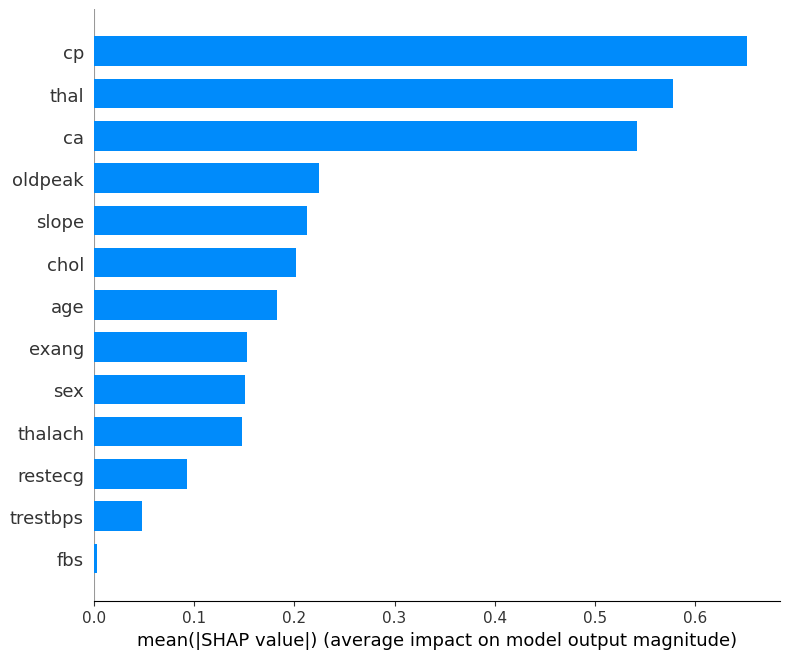

In [45]:
shap.summary_plot(shap_values, X_test, plot_type='bar')

Same top 3 as before: `ca`, `thal`, `cp`. Consistent with permutation importance and the correlation plot.

### Summary plot — direction and magnitude

Each dot is one patient. Horizontal position = SHAP value, color = actual feature value (red = high, blue = low).

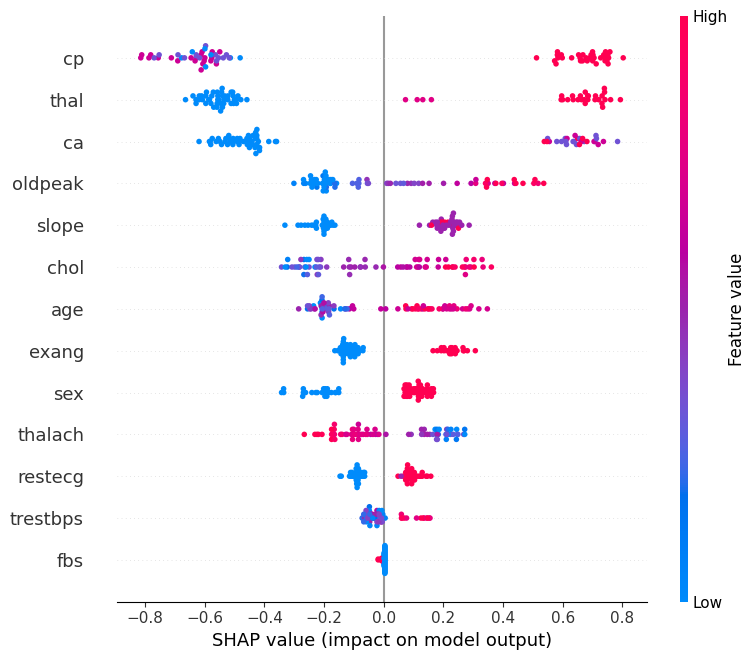

In [46]:
shap.summary_plot(shap_values, X_test)

`cp`, `thal`, `ca` have a clear color/position pattern — high values consistently push in one direction.

`chol`, `restecg`, `trestbps`, `fbs` are just noise — no pattern, SHAP near zero.

### Waterfall plot — single patient breakdown

Shows exactly how each feature contributed to a specific prediction, starting from the base rate. Useful if you need to explain a result to someone.

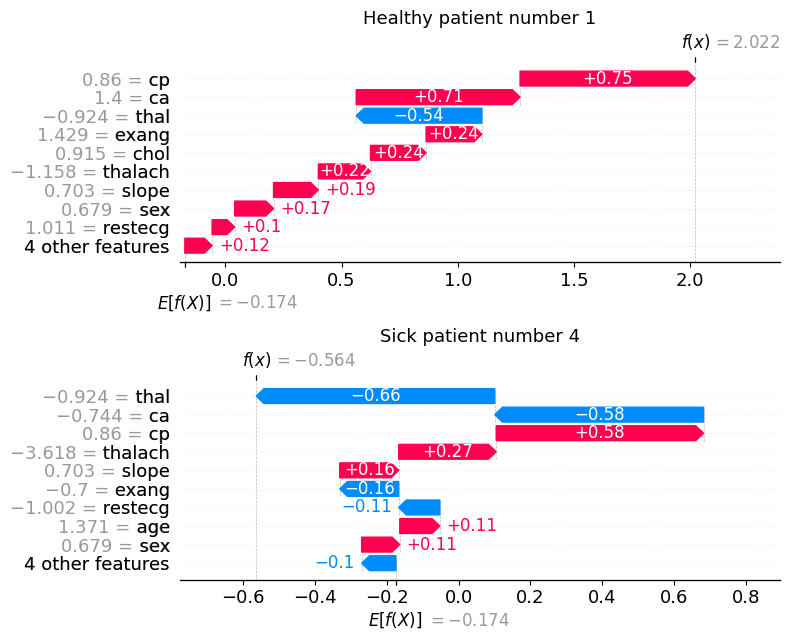

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(10,16))

#healthy patient
patient_idx_0=1

plt.sca(axes[0])
shap.waterfall_plot(shap.Explanation(
    values=shap_values[patient_idx_0],
    base_values=explainer.expected_value,
    data=X_test.iloc[patient_idx_0],
    feature_names=X_test.columns.tolist()
), show=False)
axes[0].set_title("Healthy patient number 1", fontsize=13)

#sick patient
patient_idx_1=4

plt.sca(axes[1])
shap.waterfall_plot(shap.Explanation(
    values=shap_values[patient_idx_1],
    base_values=explainer.expected_value,
    data=X_test.iloc[patient_idx_1],
    feature_names=X_test.columns.tolist()
), show=False)
axes[1].set_title('Sick patient number 4', fontsize=13)

plt.tight_layout()
plt.show()



Again `thal`, `ca` and `cp` doing most of the work.

### Dependence plot — `ca` vs `thal`

Checking if there's an interaction between the two top features.

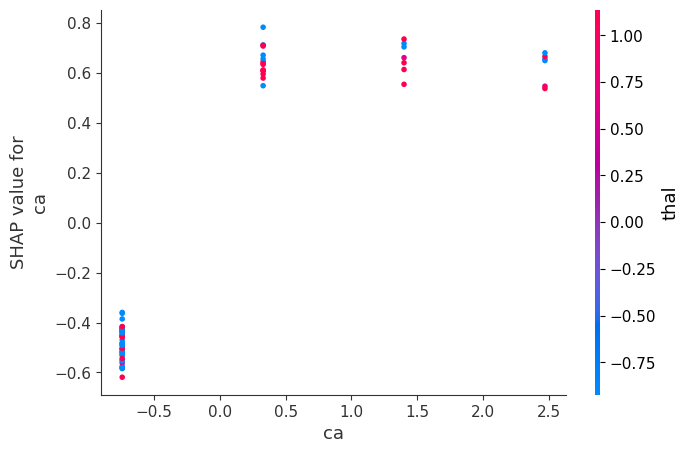

In [48]:
shap.dependence_plot('ca', shap_values, X_test, interaction_index='thal')

Low `ca` → strong negative SHAP (model leans healthy). High `ca` → strong positive SHAP (model leans sick).

Color mixing is even at all `ca` values → `thal` doesn't really interact with `ca` here.

### Takeaways

SHAP confirms what we saw in section 7 but adds directionality and patient-level detail. The waterfall plot is handy if you ever need to justify a specific prediction.

## 11. Conclusion

`ca`, `thal` and `cp` are the most consistent predictors — every method points to them. The three models all perform similarly, which suggests the signal here is mostly linear.

Optimizing for recall was the right call for this kind of problem. A false negative in a clinical screening is a much bigger issue than a false positive.

**Limitations:** only 303 observations from one center in the 80s. Results are exploratory, not clinically validated. Cross-population analysis wasn't possible due to missing data.

Next step would be testing on a larger and more recent dataset to see if these features hold up across different populations.